In [1]:
import numpy as np
import netCDF4 as nc
import geospatialtools.gdal_tools as gdal_tools
import matplotlib.pyplot as plt
import os

# ============================================================
# OUTPUT PATH
# ============================================================

outputdir = "/scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/output_plots"
os.makedirs(outputdir, exist_ok=True)

# ============================================================
# FULL 1600-CID PATH
# ============================================================

path = "/scratch/alpine/battobrah@xsede.org/Rice_NMT_Snow/upper_colorado/experiments/simulations/MSWX_3h_Snow_Project3_pp_upper_colorado_11yrs_100hru_100bh_test/"

print("Simulation path:", path, flush=True)

# ============================================================
# SETTINGS
# ============================================================

buffer = 0
cid_list = range(1, 1601)

var = "smc"
soil_layer = 0          # top soil layer
season_name = "Fall_SON"
season_months = [9, 10, 11]

# ============================================================
# READ HRU AND CID MAPS
# ============================================================

hrus = gdal_tools.read_raster(path + "postprocess/hrus.vrt")
cids = gdal_tools.read_raster(path + "postprocess/cids.vrt")
metad = gdal_tools.retrieve_metadata(path + "postprocess/hrus.vrt")

print(metad, flush=True)

coord_xx0 = np.linspace(metad["minx"], metad["maxx"], metad["nx"])
coord_yy0 = np.linspace(metad["miny"], metad["maxy"], metad["ny"])

coords_x = coord_xx0[buffer:np.size(coord_xx0)-buffer+1]
coords_y = coord_yy0[buffer:np.size(coord_yy0)-buffer+1]

# ============================================================
# PLACE DATA FUNCTION
# ============================================================

def place_data(tmp, model, hrus, cids, val):
    for i in range(tmp.shape[0]):
        for j in range(tmp.shape[1]):
            hru = int(hrus[i, j])
            ucid = int(cids[i, j])

            if (hru != -9999) and (ucid == val):
                tmp[i, j] = model[hru]

    return tmp

# ============================================================
# FALL SEASON SMC MAP
# ============================================================

print("\nPlotting", season_name, flush=True)

tmp = np.copy(hrus).astype(float)
tmp[:] = -9999.0

for c in cid_list:

    if c % 50 == 0:
        print(" Processing CID", c, flush=True)

    fp_path = path + f"{c}/output.nc"

    if not os.path.exists(fp_path):
        print("Missing:", fp_path, flush=True)
        continue

    fp = nc.Dataset(fp_path)

    if "Output" in fp.groups:
        grp = fp.groups["Output"]
    elif "output" in fp.groups:
        grp = fp.groups["output"]
    else:
        print("No output group in CID", c, flush=True)
        fp.close()
        continue

    if var not in grp.variables:
        print(var, "missing in CID", c, flush=True)
        fp.close()
        continue

    smc = np.array(grp.variables[var][:])

    time = np.array(grp.variables["time"][:])
    time_units = grp.variables["time"].units
    time_calendar = getattr(grp.variables["time"], "calendar", "standard")

    dates = nc.num2date(
        time,
        units=time_units,
        calendar=time_calendar,
        only_use_cftime_datetimes=False,
        only_use_python_datetimes=True
    )

    months = np.array([d.month for d in dates])
    season_idx = np.isin(months, season_months)

    if np.sum(season_idx) == 0:
        print("No Fall timesteps in CID", c, flush=True)
        fp.close()
        continue

    if smc.ndim == 3:
        # expected shape: time, hru, soil_layer
        seasonal_mean = np.nanmean(smc[season_idx, :, soil_layer], axis=0)

    elif smc.ndim == 4:
        # fallback if shape has an extra dimension
        seasonal_mean = np.nanmean(smc[season_idx, :, soil_layer, 0], axis=0)

    else:
        print("Unexpected smc shape in CID", c, smc.shape, flush=True)
        fp.close()
        continue

    tmp = place_data(tmp, seasonal_mean, hrus, cids, int(c))

    fp.close()

# ============================================================
# MASK AND PLOT
# ============================================================

final_map = np.ma.masked_array(tmp, tmp == -9999)
final_map[final_map == -9999] = np.nan

map_shape = final_map.shape

final_map = final_map[
    buffer:map_shape[0]-buffer+1,
    buffer:map_shape[1]-buffer+1
]

fig, ax = plt.subplots(figsize=(10, 8))

im = ax.pcolormesh(
    coords_x,
    coords_y,
    np.flipud(final_map),
    cmap="viridis",
    shading="auto",
    vmin=0.0,
    vmax=0.5
)

ax.set_title("Top-layer Soil Moisture - Fall SON")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")

fig.colorbar(
    im,
    ax=ax,
    shrink=0.98,
    fraction=0.046,
    pad=0.04,
    label="SMC"
)

plt.tight_layout()

outfile = os.path.join(
    outputdir,
    "fall_top_layer_smc_1600cid.png"
)

plt.savefig(outfile, dpi=300, bbox_inches="tight")

print("Saved:", outfile, flush=True)

plt.show()
plt.close(fig)

Simulation path: /scratch/alpine/battobrah@xsede.org/Rice_NMT_Snow/upper_colorado/experiments/simulations/MSWX_3h_Snow_Project3_pp_upper_colorado_11yrs_100hru_100bh_test/
{'proj4': '+proj=longlat +datum=WGS84 +no_defs', 'minx': -114.25041666666561, 'miny': 33.74958333333305, 'maxx': -103.74958333333265, 'maxy': 44.25041666666601, 'resx': 0.0008333333333333041, 'resy': -0.0008333333333333041, 'gt': (-114.25041666666561, 0.0008333333333333041, 0.0, 44.25041666666601, 0.0, -0.0008333333333333041), 'nx': 12601, 'ny': 12601, 'projection': 'GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AXIS["Latitude",NORTH],AXIS["Longitude",EAST],AUTHORITY["EPSG","4326"]]'}

Plotting Fall_SON
Missing: /scratch/alpine/battobrah@xsede.org/Rice_NMT_Snow/upper_colorado/experiments/simulations/MSWX_3h_Snow_Project3_pp_upper_colorado_11yrs_100hru_100bh_tes

: 

: 

In [1]:
import os
import glob
import numpy as np
import pandas as pd
import netCDF4 as nc
import matplotlib.pyplot as plt
import geospatialtools.gdal_tools as gdal_tools

# ============================================================
# PATHS
# ============================================================

outputdir = "/scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/output_plots"
os.makedirs(outputdir, exist_ok=True)

path = "/scratch/alpine/battobrah@xsede.org/Rice_NMT_Snow/upper_colorado/experiments/simulations/MSWX_3h_Snow_Project3_pp_upper_colorado_11yrs_100hru_100bh_test/"
output_path = path + "postprocess/output_dir/"

print("Simulation path:", path, flush=True)
print("Output path:", output_path, flush=True)

# ============================================================
# SETTINGS
# ============================================================

soil_layer = 0
season_months = [9, 10, 11]   # Fall: SON

# ============================================================
# READ HRU MAP
# ============================================================

hrus = gdal_tools.read_raster(path + "postprocess/hrus.vrt").astype(np.int32)
metad = gdal_tools.retrieve_metadata(path + "postprocess/hrus.vrt")

coords_x = np.linspace(metad["minx"], metad["maxx"], metad["nx"])
coords_y = np.linspace(metad["miny"], metad["maxy"], metad["ny"])

# ============================================================
# READ FALL SMC FILES AND COMPUTE MEAN
# ============================================================

files = sorted(glob.glob(output_path + "*.nc"))

smc_sum = None
count_sum = None

for n, fp_path in enumerate(files):

    date = pd.to_datetime(
        os.path.basename(fp_path).replace(".nc", ""),
        format="%Y%m%d"
    )

    if date.month not in season_months:
        continue

    if n % 50 == 0:
        print("Processing", os.path.basename(fp_path), flush=True)

    fp = nc.Dataset(fp_path)

    if "data" in fp.groups:
        grp = fp.groups["data"]
    elif "Output" in fp.groups:
        grp = fp.groups["Output"]
    else:
        grp = fp

    smc = np.array(grp.variables["smc"][:])

    # Expected shape: time, hru, soil_layer
    smc_top = smc[:, :, soil_layer]

    daily_sum = np.nansum(smc_top, axis=0)
    daily_count = np.sum(np.isfinite(smc_top), axis=0)

    if smc_sum is None:
        smc_sum = np.zeros_like(daily_sum, dtype=float)
        count_sum = np.zeros_like(daily_count, dtype=float)

    smc_sum += daily_sum
    count_sum += daily_count

    fp.close()

fall_mean_smc = smc_sum / count_sum

print("Fall mean SMC min:", np.nanmin(fall_mean_smc), flush=True)
print("Fall mean SMC max:", np.nanmax(fall_mean_smc), flush=True)

# ============================================================
# MAP HRU VALUES TO GRID
# ============================================================

final_map = np.full(hrus.shape, np.nan, dtype=float)

valid = hrus != -9999
final_map[valid] = fall_mean_smc[hrus[valid]]

# ============================================================
# PLOT
# ============================================================

fig, ax = plt.subplots(figsize=(10, 8))

im = ax.pcolormesh(
    coords_x,
    coords_y,
    np.flipud(final_map),
    cmap="viridis",
    shading="auto",
    vmin=0.0,
    vmax=0.5
)

ax.set_title("Top-layer Soil Moisture - Fall SON")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")

fig.colorbar(
    im,
    ax=ax,
    shrink=0.98,
    fraction=0.046,
    pad=0.04,
    label="SMC"
)

plt.tight_layout()

outfile = os.path.join(outputdir, "fall_top_layer_smc_1600cid.png")
plt.savefig(outfile, dpi=300, bbox_inches="tight")

print("Saved:", outfile, flush=True)

plt.show()
plt.close(fig)

Simulation path: /scratch/alpine/battobrah@xsede.org/Rice_NMT_Snow/upper_colorado/experiments/simulations/MSWX_3h_Snow_Project3_pp_upper_colorado_11yrs_100hru_100bh_test/
Output path: /scratch/alpine/battobrah@xsede.org/Rice_NMT_Snow/upper_colorado/experiments/simulations/MSWX_3h_Snow_Project3_pp_upper_colorado_11yrs_100hru_100bh_test/postprocess/output_dir/


In [1]:
import os
import glob
import numpy as np
import pandas as pd
import netCDF4 as nc
import matplotlib.pyplot as plt
import geospatialtools.gdal_tools as gdal_tools

# ============================================================
# PATHS
# ============================================================

outputdir = "/scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/output_plots"
os.makedirs(outputdir, exist_ok=True)

path = "/scratch/alpine/battobrah@xsede.org/Rice_NMT_Snow/upper_colorado/experiments/simulations/MSWX_3h_Snow_Project3_pp_upper_colorado_11yrs_100hru_100bh_test/"
output_path = path + "postprocess/output_dir/"

print("Simulation path:", path, flush=True)
print("Output path:", output_path, flush=True)

# ============================================================
# SETTINGS
# ============================================================

soil_layer = 0
season_months = [9, 10, 11]      # Fall SON
years_to_use = [2014, 2015]      # 2 years
cid_list = range(1, 1601)

# ============================================================
# READ HRU AND CID MAPS
# ============================================================

hrus = gdal_tools.read_raster(path + "postprocess/hrus.vrt").astype(np.int32)
cids = gdal_tools.read_raster(path + "postprocess/cids.vrt").astype(np.int32)
metad = gdal_tools.retrieve_metadata(path + "postprocess/hrus.vrt")

coords_x = np.linspace(metad["minx"], metad["maxx"], metad["nx"])
coords_y = np.linspace(metad["miny"], metad["maxy"], metad["ny"])

# ============================================================
# PLACE DATA FUNCTION
# ============================================================

def place_data(tmp, model, hrus, cids, val):
    for i in range(tmp.shape[0]):
        for j in range(tmp.shape[1]):
            hru = int(hrus[i, j])
            ucid = int(cids[i, j])

            if (hru != -9999) and (ucid == val):
                tmp[i, j] = model[hru]

    return tmp

# ============================================================
# READ FALL SMC FILES AND COMPUTE MEAN
# ============================================================

files = sorted(glob.glob(output_path + "*.nc"))

print("Total daily files:", len(files), flush=True)

smc_sum = None
count_sum = None

for fp_path in files:

    date = pd.to_datetime(
        os.path.basename(fp_path).replace(".nc", ""),
        format="%Y%m%d"
    )

    if date.month not in season_months:
        continue

    if date.year not in years_to_use:
        continue

    print("Reading", os.path.basename(fp_path), flush=True)

    fp = nc.Dataset(fp_path)

    if "data" in fp.groups:
        grp = fp.groups["data"]
    elif "Output" in fp.groups:
        grp = fp.groups["Output"]
    else:
        grp = fp

    smc = np.array(grp.variables["smc"][:])

    # Expected shape: time, hru, soil_layer
    smc_top = smc[:, :, soil_layer]

    daily_sum = np.nansum(smc_top, axis=0)
    daily_count = np.sum(np.isfinite(smc_top), axis=0)

    if smc_sum is None:
        smc_sum = np.zeros_like(daily_sum, dtype=float)
        count_sum = np.zeros_like(daily_count, dtype=float)

    smc_sum += daily_sum
    count_sum += daily_count

    fp.close()

fall_mean = smc_sum / count_sum

print("Fall mean shape:", fall_mean.shape, flush=True)
print("Fall mean min:", np.nanmin(fall_mean), flush=True)
print("Fall mean max:", np.nanmax(fall_mean), flush=True)

# ============================================================
# MAP HRU VALUES TO GRID USING CID-AWARE FUNCTION
# ============================================================

tmp = np.copy(hrus).astype(float)
tmp[:] = -9999.0

for c in cid_list:

    if c % 50 == 0:
        print("Mapping CID", c, flush=True)

    tmp = place_data(tmp, fall_mean, hrus, cids, int(c))

final_map = np.ma.masked_array(tmp, tmp == -9999)
final_map[final_map == -9999] = np.nan

# ============================================================
# PLOT
# ============================================================

fig, ax = plt.subplots(figsize=(10, 8))

im = ax.pcolormesh(
    coords_x,
    coords_y,
    np.flipud(final_map),
    cmap="viridis",
    shading="auto",
    vmin=0.0,
    vmax=0.5
)

ax.set_title("Top-layer Soil Moisture - Fall SON 2014-2015")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")

fig.colorbar(
    im,
    ax=ax,
    shrink=0.98,
    fraction=0.046,
    pad=0.04,
    label="SMC"
)

plt.tight_layout()

outfile = os.path.join(
    outputdir,
    "fall_top_layer_smc_2014_2015_1600cid.png"
)

plt.savefig(outfile, dpi=300, bbox_inches="tight")

print("Saved:", outfile, flush=True)

plt.show()
plt.close(fig)

Simulation path: /scratch/alpine/battobrah@xsede.org/Rice_NMT_Snow/upper_colorado/experiments/simulations/MSWX_3h_Snow_Project3_pp_upper_colorado_11yrs_100hru_100bh_test/
Output path: /scratch/alpine/battobrah@xsede.org/Rice_NMT_Snow/upper_colorado/experiments/simulations/MSWX_3h_Snow_Project3_pp_upper_colorado_11yrs_100hru_100bh_test/postprocess/output_dir/
Total daily files: 4015
Reading 20140901.nc
Reading 20140902.nc
Reading 20140903.nc
Reading 20140904.nc
Reading 20140905.nc
Reading 20140906.nc
Reading 20140907.nc
Reading 20140908.nc
Reading 20140909.nc
Reading 20140910.nc
Reading 20140911.nc
Reading 20140912.nc
Reading 20140913.nc
Reading 20140914.nc
Reading 20140915.nc
Reading 20140916.nc
Reading 20140917.nc
Reading 20140918.nc
Reading 20140919.nc
Reading 20140920.nc
Reading 20140921.nc
Reading 20140922.nc
Reading 20140923.nc
Reading 20140924.nc
Reading 20140925.nc
Reading 20140926.nc
Reading 20140927.nc
Reading 20140928.nc
Reading 20140929.nc
Reading 20140930.nc
Reading 2014100

KeyboardInterrupt: 

Simulation path: /scratch/alpine/battobrah@xsede.org/Rice_NMT_Snow/upper_colorado/experiments/simulations/MSWX_3h_Snow_Project3_pp_upper_colorado_11yrs_100hru_100bh_test/
Output path: /scratch/alpine/battobrah@xsede.org/Rice_NMT_Snow/upper_colorado/experiments/simulations/MSWX_3h_Snow_Project3_pp_upper_colorado_11yrs_100hru_100bh_test/postprocess/output_dir/
Total daily files: 4015
Reading 20140901.nc
Reading 20140902.nc
Reading 20140903.nc
Reading 20140904.nc
Reading 20140905.nc
Reading 20140906.nc
Reading 20140907.nc
Reading 20140908.nc
Reading 20140909.nc
Reading 20140910.nc
Reading 20140911.nc
Reading 20140912.nc
Reading 20140913.nc
Reading 20140914.nc
Reading 20140915.nc
Reading 20140916.nc
Reading 20140917.nc
Reading 20140918.nc
Reading 20140919.nc
Reading 20140920.nc
Reading 20140921.nc
Reading 20140922.nc
Reading 20140923.nc
Reading 20140924.nc
Reading 20140925.nc
Reading 20140926.nc
Reading 20140927.nc
Reading 20140928.nc
Reading 20140929.nc
Reading 20140930.nc
Reading 2014100

/projects/battobrah@xsede.org/code-server/tmp/ipykernel_1655290/2397849614.py:91: RuntimeWarning: invalid value encountered in true_divide
  fall_mean = smc_sum / count_sum


Saved: /scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/output_plots/fall_top_layer_smc_2014_2015_gridded.png


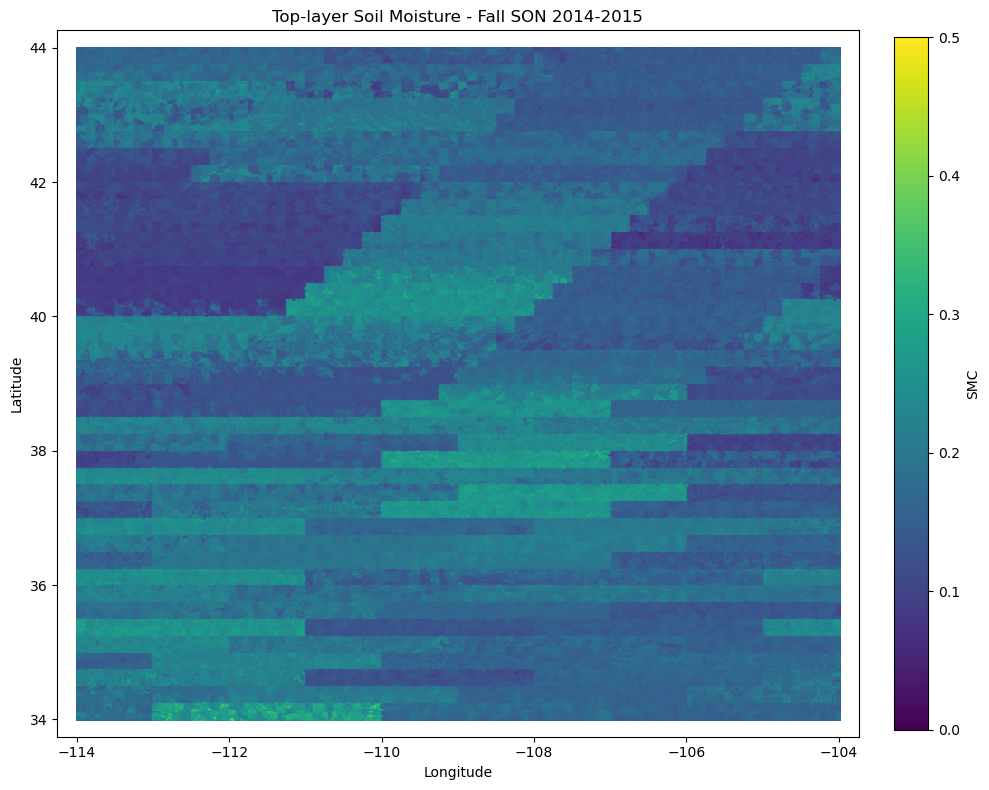

In [4]:
import os
import glob
import numpy as np
import pandas as pd
import netCDF4 as nc
import matplotlib.pyplot as plt
import geospatialtools.gdal_tools as gdal_tools

# ============================================================
# PATHS
# ============================================================

outputdir = "/scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/output_plots"
os.makedirs(outputdir, exist_ok=True)

path = "/scratch/alpine/battobrah@xsede.org/Rice_NMT_Snow/upper_colorado/experiments/simulations/MSWX_3h_Snow_Project3_pp_upper_colorado_11yrs_100hru_100bh_test/"
output_path = path + "postprocess/output_dir/"

print("Simulation path:", path, flush=True)
print("Output path:", output_path, flush=True)

# ============================================================
# SETTINGS
# ============================================================

season_months = [9, 10, 11]      # Fall SON
years_to_use = [2014, 2015]      # 2 years

# ============================================================
# READ MAP METADATA FOR COORDINATES
# ============================================================

metad = gdal_tools.retrieve_metadata(path + "postprocess/hrus.vrt")

coords_x = np.linspace(metad["minx"], metad["maxx"], 630)
coords_y = np.linspace(metad["miny"], metad["maxy"], 630)

# ============================================================
# READ FALL SMC FILES AND COMPUTE MEAN
# ============================================================

files = sorted(glob.glob(output_path + "*.nc"))

print("Total daily files:", len(files), flush=True)

smc_sum = None
count_sum = None

for fp_path in files:

    date = pd.to_datetime(
        os.path.basename(fp_path).replace(".nc", ""),
        format="%Y%m%d"
    )

    if date.month not in season_months:
        continue

    if date.year not in years_to_use:
        continue

    print("Reading", os.path.basename(fp_path), flush=True)

    fp = nc.Dataset(fp_path)

    if "data" in fp.groups:
        grp = fp.groups["data"]
    elif "Output" in fp.groups:
        grp = fp.groups["Output"]
    else:
        grp = fp

    smc = np.array(grp.variables["smc"][:]).astype(float)

    # Mask missing values
    smc[smc <= -9990] = np.nan

    # smc shape is (time, lat, lon)
    daily_sum = np.nansum(smc, axis=0)
    daily_count = np.sum(np.isfinite(smc), axis=0)

    if smc_sum is None:
        smc_sum = np.zeros_like(daily_sum, dtype=float)
        count_sum = np.zeros_like(daily_count, dtype=float)

    smc_sum += daily_sum
    count_sum += daily_count

    fp.close()

fall_mean = smc_sum / count_sum

print("Fall mean shape:", fall_mean.shape, flush=True)
print("Fall mean min:", np.nanmin(fall_mean), flush=True)
print("Fall mean max:", np.nanmax(fall_mean), flush=True)

# ============================================================
# PLOT
# ============================================================

fig, ax = plt.subplots(figsize=(10, 8))

im = ax.pcolormesh(
    coords_x,
    coords_y,
    np.flipud(fall_mean),
    cmap="viridis",
    shading="auto",
    vmin=0.0,
    vmax=0.5
)

ax.set_title("Top-layer Soil Moisture - Fall SON 2014-2015")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")

fig.colorbar(
    im,
    ax=ax,
    shrink=0.98,
    fraction=0.046,
    pad=0.04,
    label="SMC"
)

plt.tight_layout()

outfile = os.path.join(
    outputdir,
    "fall_top_layer_smc_2014_2015_gridded.png"
)

plt.savefig(outfile, dpi=300, bbox_inches="tight")

print("Saved:", outfile, flush=True)

plt.show()
plt.close(fig)

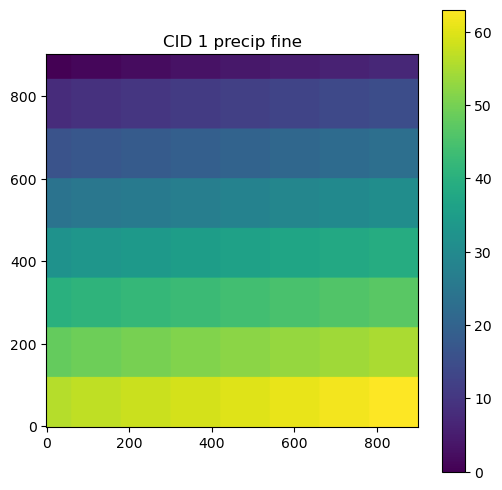

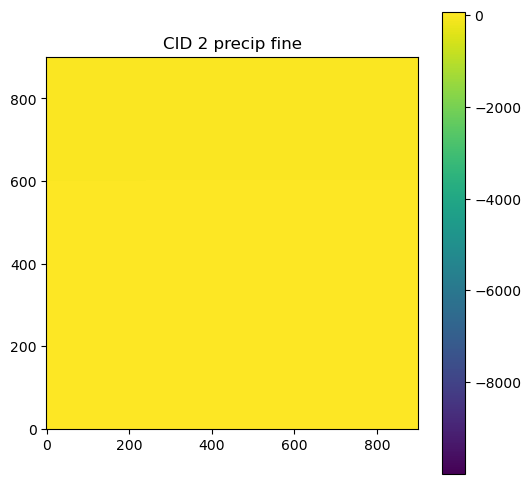

In [6]:
import matplotlib.pyplot as plt
import geospatialtools.gdal_tools as gdal_tools

base = "/scratch/alpine/battobrah@xsede.org/Rice_NMT_Snow/upper_colorado/data/cids"

for cid in [1, 2]:
    f = f"{base}/{cid}/precip_latlon_fine.tif"

    arr = gdal_tools.read_raster(f)

    plt.figure(figsize=(6,6))
    plt.imshow(arr, origin="lower")
    plt.colorbar()
    plt.title(f"CID {cid} precip fine")
    plt.show()

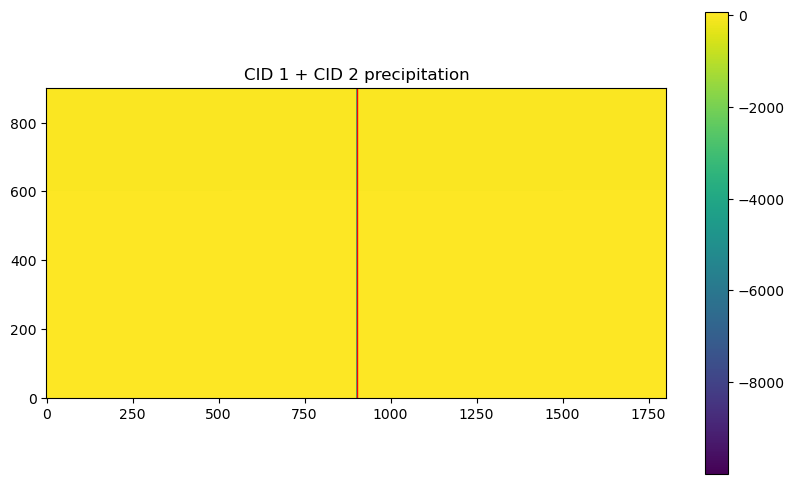

In [8]:
import numpy as np
import matplotlib.pyplot as plt
import geospatialtools.gdal_tools as gdal_tools

base = "/scratch/alpine/battobrah@xsede.org/Rice_NMT_Snow/upper_colorado/data/cids"

left  = gdal_tools.read_raster(f"{base}/1/precip_latlon_fine.tif")
right = gdal_tools.read_raster(f"{base}/2/precip_latlon_fine.tif")

merged = np.hstack((left, right))

plt.figure(figsize=(10, 6))
plt.imshow(merged, origin="lower")
plt.colorbar()
plt.axvline(left.shape[1], color="red", linewidth=1)
plt.title("CID 1 + CID 2 precipitation")
plt.show()

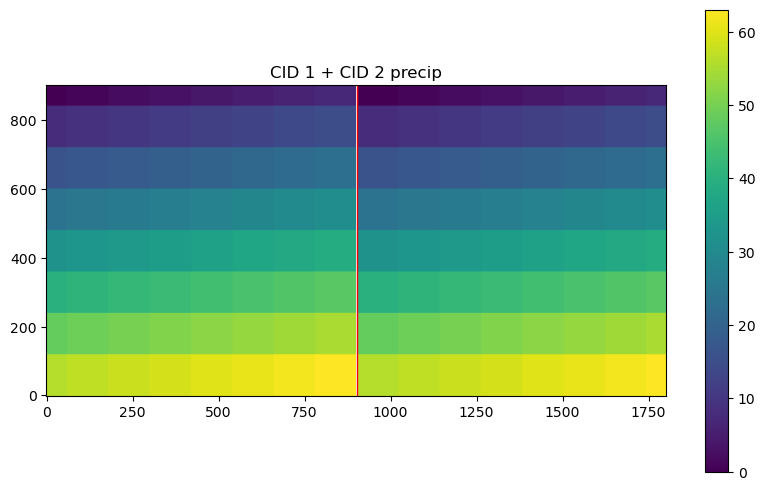

Left : 0.0 63.0
Right: 0.0 63.0


In [9]:
left = gdal_tools.read_raster(f"{base}/1/precip_latlon_fine.tif").astype(float)
right = gdal_tools.read_raster(f"{base}/2/precip_latlon_fine.tif").astype(float)

left[left <= -9990] = np.nan
right[right <= -9990] = np.nan

merged = np.hstack((left, right))

plt.figure(figsize=(10,6))
im = plt.imshow(merged, origin="lower")
plt.colorbar(im)
plt.axvline(left.shape[1], color="red", lw=1)
plt.title("CID 1 + CID 2 precip")
plt.show()

print("Left :", np.nanmin(left), np.nanmax(left))
print("Right:", np.nanmin(right), np.nanmax(right))

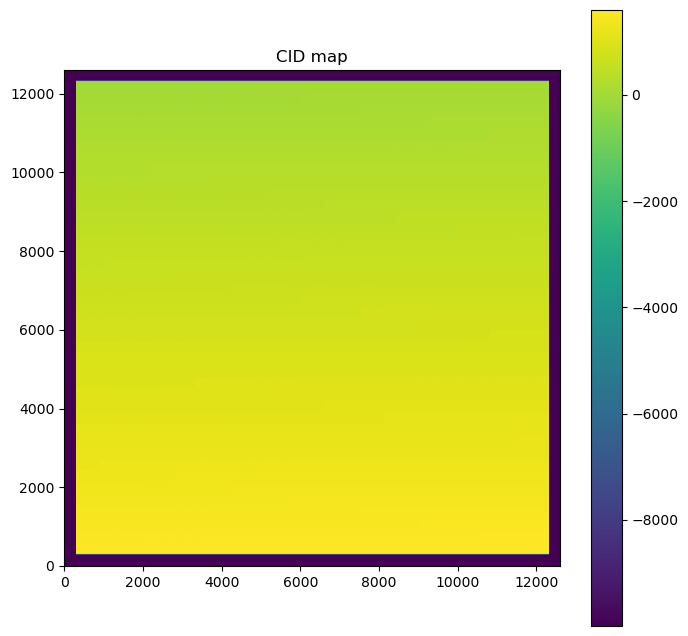

In [10]:
import matplotlib.pyplot as plt
import geospatialtools.gdal_tools as gdal_tools

cids = gdal_tools.read_raster(
    "/scratch/alpine/battobrah@xsede.org/Rice_NMT_Snow/upper_colorado/experiments/simulations/MSWX_3h_Snow_Project3_pp_upper_colorado_11yrs_100hru_100bh_test/postprocess/cids.vrt"
)

plt.figure(figsize=(8,8))
plt.imshow(cids, origin="lower")
plt.colorbar()
plt.title("CID map")
plt.show()